# MovieLens-1M Movie Overviews Enrichment

???? notebook ????????? ????????? ????? ???????????? `research/movie_overviews`: ?????? `movies.dat`, ????????? `movie_id/title/year/genres`, ????????? ???????? ?? title+year ? ??????? TMDb-derived ????????? ? ????????? ???????? CSV.

???????? ????????: Hugging Face dataset `mt0rm0/movie_descriptors`, CC0 subset ?? Kaggle `The Movie Dataset`, ??? `overview` ??????? ?? TMDb-derived metadata. Live TMDb/OMDb ?????????? ? ??????? ??? ??????? API keys, ?? ??????? ??????????? ?????? ?????????? `--providers hf`, ????? ?? ???????? ?? API ???????.

In [1]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().parents[2] if Path.cwd().name == "notebooks" else Path.cwd()
SCRIPT_PATH = ROOT / "research/movie_overviews/scripts/build_ml1m_movie_overviews.py"
CSV_PATH = ROOT / "research/movie_overviews/data/ml1m_movie_overviews.csv"
CACHE_PATH = ROOT / "research/movie_overviews/cache/movie_overviews_hf_cache.jsonl"

{
    "script": str(SCRIPT_PATH),
    "csv": str(CSV_PATH),
    "cache": str(CACHE_PATH),
}

{'script': 'C:\\Users\\User\\plum-ml1m-repro\\research\\movie_overviews\\scripts\\build_ml1m_movie_overviews.py', 'csv': 'C:\\Users\\User\\plum-ml1m-repro\\research\\movie_overviews\\data\\ml1m_movie_overviews.csv', 'cache': 'C:\\Users\\User\\plum-ml1m-repro\\research\\movie_overviews\\cache\\movie_overviews_hf_cache.jsonl'}

In [2]:
import subprocess

cmd = [
    "python", str(SCRIPT_PATH),
    "--providers", "hf",
    "--output-path", str(CSV_PATH),
    "--cache-path", str(CACHE_PATH),
    "--force",
    "--sleep", "0.0",
]
result = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True, encoding="utf-8", errors="replace")
print(result.stdout)
if result.returncode != 0:
    raise RuntimeError(result.stderr)

[   1/3883] found=   1 coverage=100.0%
[ 100/3883] found=  95 coverage=95.0%
[ 200/3883] found= 186 coverage=93.0%
[ 300/3883] found= 274 coverage=91.3%
[ 400/3883] found= 359 coverage=89.8%
[ 500/3883] found= 450 coverage=90.0%
[ 600/3883] found= 534 coverage=89.0%
[ 700/3883] found= 608 coverage=86.9%
[ 800/3883] found= 691 coverage=86.4%
[ 900/3883] found= 768 coverage=85.3%
[1000/3883] found= 860 coverage=86.0%
[1100/3883] found= 946 coverage=86.0%
[1200/3883] found=1024 coverage=85.3%
[1300/3883] found=1114 coverage=85.7%
[1400/3883] found=1202 coverage=85.9%
[1500/3883] found=1293 coverage=86.2%
[1600/3883] found=1382 coverage=86.4%
[1700/3883] found=1462 coverage=86.0%
[1800/3883] found=1543 coverage=85.7%
[1900/3883] found=1638 coverage=86.2%
[2000/3883] found=1725 coverage=86.2%
[2100/3883] found=1816 coverage=86.5%
[2200/3883] found=1899 coverage=86.3%
[2300/3883] found=1984 coverage=86.3%
[2400/3883] found=2080 coverage=86.7%
[2500/3883] found=2170 coverage=86.8%
[2600/3883]

## ???????? ????????? CSV

??????????: ??? ?????? ???????? ? ????????; ??? `no_description` ???? `overview` ??????; ??? `found` ???? `overview` ????????.

In [3]:
df = pd.read_csv(CSV_PATH)
summary = pd.DataFrame([
    {"metric": "rows", "value": len(df)},
    {"metric": "found", "value": int((df.status == "found").sum())},
    {"metric": "no_description", "value": int((df.status == "no_description").sum())},
    {"metric": "coverage", "value": round(float((df.status == "found").mean()), 4)},
    {"metric": "found_empty_overview", "value": int(((df.status == "found") & (df.overview.fillna("").str.len() == 0)).sum())},
    {"metric": "no_description_nonempty_overview", "value": int(((df.status != "found") & (df.overview.fillna("").str.len() > 0)).sum())},
])
summary

metric,value
rows,3883.000
found,3382.000
no_description,501.000
coverage,0.871
found_empty_overview,0.000
no_description_nonempty_overview,0.000


In [4]:
df.head(10)

movie_id,title,year,genres,overview,source,status
1,Toy Story (1995),1995,Animation|Children's|Comedy,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
2,Jumanji (1995),1995,Adventure|Children's|Fantasy,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures.",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
3,Grumpier Old Men (1995),1995,Comedy|Romance,"A family wedding reignites the ancient feud between next-door neighbors and fishing buddies John and Max. Meanwhile, a sultry Italian divorcée opens a restaurant at the local bait shop, alarming the locals who worry she'll scare the fish away. But she's less interested in seafood than she is in cooking up a hot time with Max.",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
4,Waiting to Exhale (1995),1995,Comedy|Drama,"Cheated on, mistreated and stepped on, the women are holding their breath, waiting for the elusive ""good man"" to break a string of less-than-stellar lovers. Friends and confidants Vannah, Bernie, Glo and Robin talk it all out, determined to find a better way to breathe.",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
5,Father of the Bride Part II (1995),1995,Comedy,"Just when George Banks has recovered from his daughter's wedding, he receives the news that she's pregnant ... and that George's wife, Nina, is expecting too. He was planning on selling their home, but that's a plan that -- like George -- will have to change with the arrival of both a grandchild and a kid of his own.",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
6,Heat (1995),1995,Action|Crime|Thriller,"Obsessive master thief, Neil McCauley leads a top-notch crew on various insane heists throughout Los Angeles while a mentally unstable detective, Vincent Hanna pursues him without rest. Each man recognizes and respects the ability and the dedication of the other even though they are aware their cat-and-mouse game may end in violence.",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
7,Sabrina (1995),1995,Comedy|Romance,"An ugly duckling having undergone a remarkable change, still harbors feelings for her crush: a carefree playboy, but not before his business-focused brother has something to say about it.",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
8,Tom and Huck (1995),1995,Adventure|Children's,"A mischievous young boy, Tom Sawyer, witnesses a murder by the deadly Injun Joe. Tom becomes friends with Huckleberry Finn, a boy with no future and no family. Tom has to choose between honoring a friendship or honoring an oath because the town alcoholic is accused of the murder. Tom and Huck go through several adventures trying to retrieve evidence.",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
9,Sudden Death (1995),1995,Action,"International action superstar Jean Claude Van Damme teams with Powers Boothe in a Tension-packed, suspense thriller, set against the back-drop of a Stanley Cup game.Van Damme portrays a father whose daughter is suddenly taken during a championship hockey game. With the captors demanding a billion dollars by game's end, Van Damme frantically sets a plan in motion to rescue his daughter and abort an impending explosion before the final buzzer...",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
10,GoldenEye (19

## ??????? ????????? ????????

In [5]:
found_sample = df[df.status.eq("found")][["movie_id", "title", "year", "genres", "overview", "source", "status"]].head(8).copy()
found_sample["overview"] = found_sample["overview"].str.slice(0, 180) + "..."
found_sample

movie_id,title,year,genres,overview,source,status
1,Toy Story (1995),1995,Animation|Children's|Comedy,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz....",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
2,Jumanji (1995),1995,Adventure|Children's|Fantasy,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game fo...",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
3,Grumpier Old Men (1995),1995,Comedy|Romance,"A family wedding reignites the ancient feud between next-door neighbors and fishing buddies John and Max. Meanwhile, a sultry Italian divorcée opens a restaurant at the local bait ...",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
4,Waiting to Exhale (1995),1995,Comedy|Drama,"Cheated on, mistreated and stepped on, the women are holding their breath, waiting for the elusive ""good man"" to break a string of less-than-stellar lovers. Friends and confidants ...",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
5,Father of the Bride Part II (1995),1995,Comedy,"Just when George Banks has recovered from his daughter's wedding, he receives the news that she's pregnant ... and that George's wife, Nina, is expecting too. He was planning on se...",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
6,Heat (1995),1995,Action|Crime|Thriller,"Obsessive master thief, Neil McCauley leads a top-notch crew on various insane heists throughout Los Angeles while a mentally unstable detective, Vincent Hanna pursues him without ...",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
7,Sabrina (1995),1995,Comedy|Romance,"An ugly duckling having undergone a remarkable change, still harbors feelings for her crush: a carefree playboy, but not before his business-focused brother has something to say ab...",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found
8,Tom and Huck (1995),1995,Adventure|Children's,"A mischievous young boy, Tom Sawyer, witnesses a murder by the deadly Injun Joe. Tom becomes friends with Huckleberry Finn, a boy with no future and no family. Tom has to choose be...",https://huggingface.co/datasets/mt0rm0/movie_descriptors,found


## ??????? ??????? ??? ????????

??? ?????? ????????? ? CSV, ??? ? ???????????. ??? ??? `overview` ? `source` ??????, `status = no_description`.

In [6]:
missing_sample = df[df.status.eq("no_description")][["movie_id", "title", "year", "genres", "status"]].head(15)
missing_sample

movie_id,title,year,genres,status
33,Wings of Courage (1995),1995,Adventure|Romance,no_description
56,Kids of the Round Table (1995),1995,Adventure|Children's|Fantasy,no_description
73,"Misérables, Les (1995)",1995,Drama|Musical,no_description
83,Once Upon a Time... When We Were Colored (1995),1995,Drama,no_description
96,In the Bleak Midwinter (1995),1995,Comedy,no_description
106,Nobody Loves Me (Keiner liebt mich) (1994),1994,Comedy|Drama,no_description
121,"Boys of St. Vincent, The (1993)",1993,Drama,no_description
126,"NeverEnding Story III, The (1994)",1994,Adventure|Children's|Fantasy,no_description
128,Jupiter's Wife (1994),1994,Documentary,no_description
129,Pie in the Sky (1995),1995,Comedy|Romance,no_description


## Coverage ?? ??????

In [7]:
by_genre = df.assign(genre=df["genres"].str.split("|")).explode("genre")
by_genre = (
    by_genre.groupby("genre", dropna=False)
    .agg(rows=("movie_id", "count"), found=("status", lambda s: int((s == "found").sum())))
    .reset_index()
)
by_genre["coverage"] = by_genre["found"] / by_genre["rows"]
by_genre.sort_values(["coverage", "rows"], ascending=[False, False])

genre,rows,found,coverage
Fantasy,68,66,0.970588
Film-Noir,44,42,0.954545
Mystery,106,100,0.943396
Musical,114,107,0.938596
Sci-Fi,276,256,0.927536
Western,68,63,0.926471
Thriller,492,454,0.922764
Adventure,283,261,0.922261
Action,503,463,0.920477
Children's,251,229,0.912351


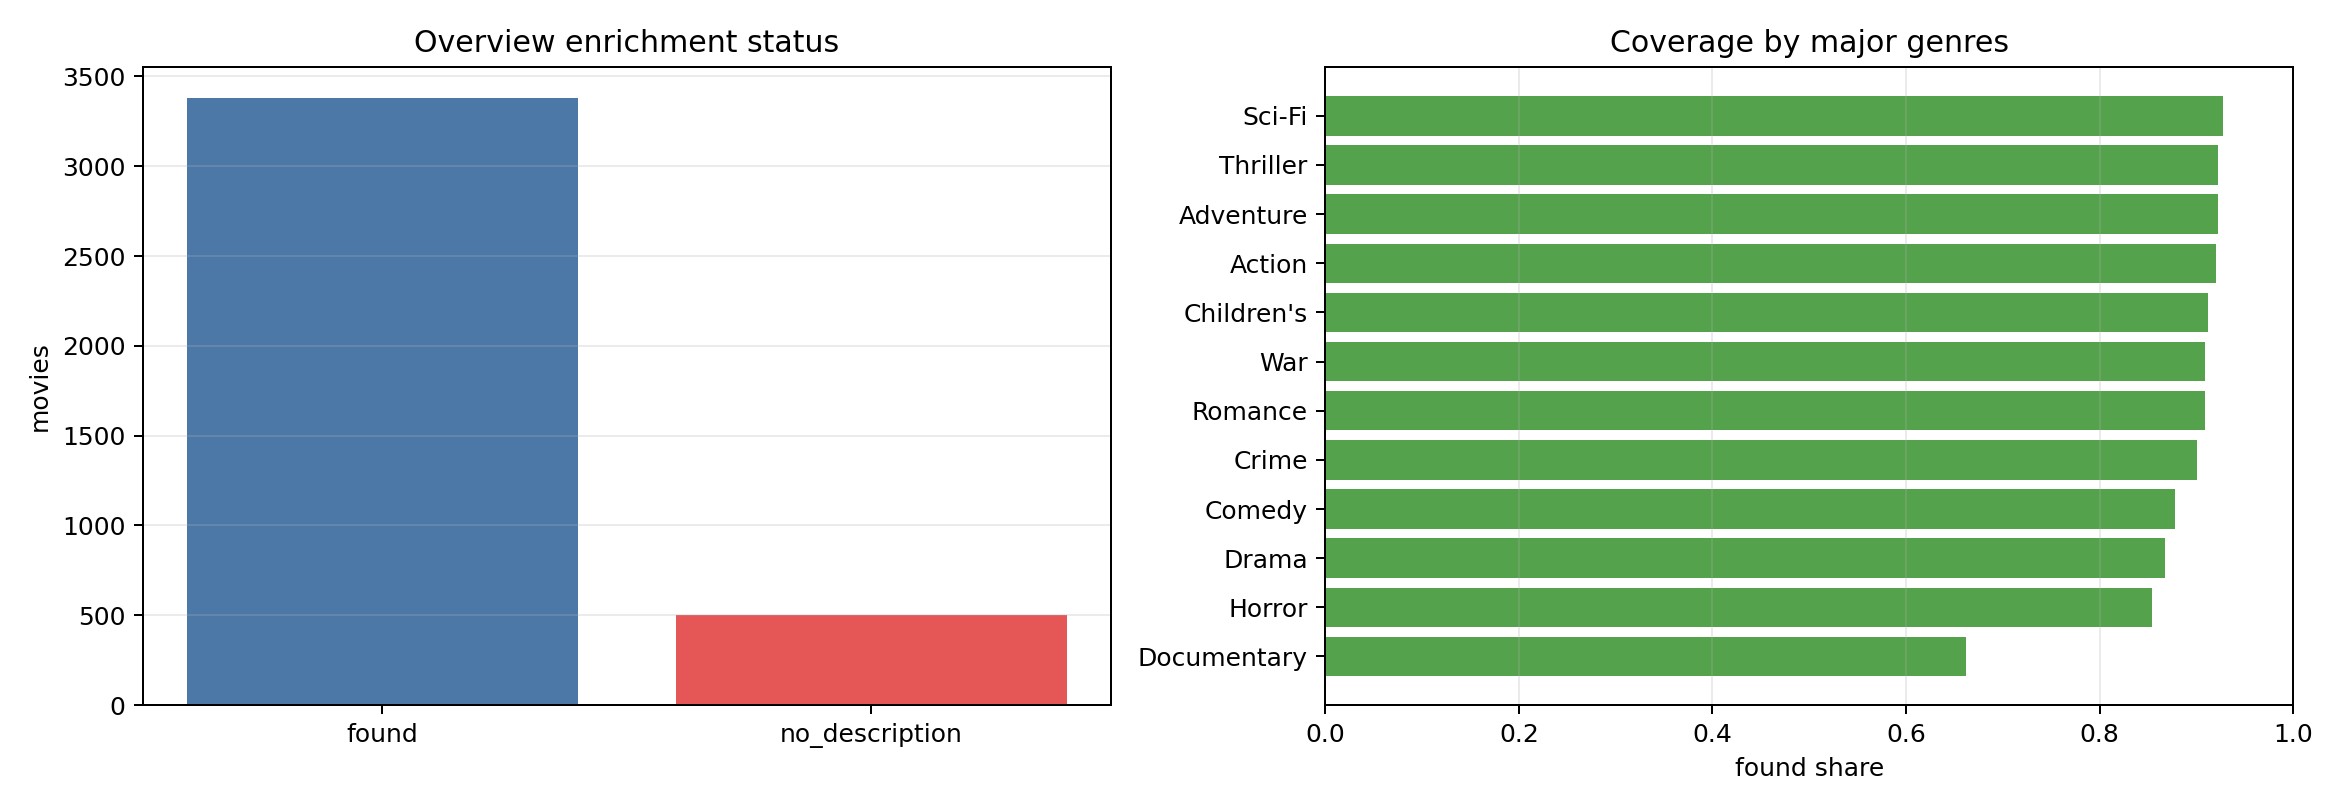

In [8]:
from IPython.display import Image, display

PLOT_PATH = ROOT / "research/movie_overviews/data/movie_overview_status_by_genre.png"
display(Image(filename=str(PLOT_PATH)))

## ????????? ?? ????????

- ???????? ??????? ???????: ??????????????? ???????? + ??? ??????.
- ??????????? ?????????? ???????? ?? ?????? MovieLens-title: ???????????? ???????? (`American President, The` -> `The American President`), ???????????? ? ??????? (`Seven (Se7en)`), ? ????? subtitle-????????.
- ???? ?????????? ?????????????, ?????? ?? ?????????? ???????? ? ????????? `status = no_description`.
- Live Wikipedia fallback ? ??????? ????, ?? ?? ??????????? ? ???????? ??????????? ???????: Wikimedia ??????? rate limit ??? ???????? ???????, ??????? ????????? CSV ?????? ????? ???????? ?????????????? CC0 TMDb-derived descriptor dataset.